## Instalamos paquetes y librerías

In [1]:
# Importamos las librerias necesarias:
from diffusers import StableDiffusionPipeline, DDPMScheduler, UNet2DConditionModel, AutoencoderKL, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from datasets import load_dataset
from accelerate import Accelerator
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


## Selección de procesador en Mac M1

Para el entrenamiento se probó inicialmente el uso de la GPU del Mac mediante el backend MPS de PyTorch, con el objetivo de reducir el tiempo de ejecución frente a CPU. Efectivamente, MPS permitía acelerar el proceso, pero durante las pruebas aparecieron problemas de estabilidad numérica.

En concreto, aunque el forward inicial del modelo funcionaba correctamente, tras el primer `optimizer.step()` la U-Net comenzaba a producir valores inválidos (`NaN/Inf`), lo que terminaba generando pérdidas no finitas (`loss = NaN`) e inutilizaba el modelo entrenado. También aparecieron errores de memoria en algunos intentos, especialmente al trabajar con resolución 512x512.

Para intentar mitigar estos problemas se aplicaron varias medidas: reducción de la resolución de entrenamiento a 384x384, activación de `gradient checkpointing`y reducción del learning rate. Aun así, la inestabilidad en MPS persistió.

Por este motivo, finalmente se optó por ejecutar el fine-tuning en CPU, sacrificando velocidad a cambio de estabilidad. Aunque el entrenamiento en CPU resultó más lento, permitió completar el proceso sin que apareciesen valores inválidos en la pérdida.


In [2]:
import torch
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

# device = "mps" if torch.backends.mps.is_available() else "cpu"

device = torch.device("cpu")
print(device)

MPS available: True
MPS built: True
cpu


## Comportamiento original modelo pre-entrenado 

In [3]:
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    torch_dtype=torch.float32
).to(device)

Loading weights: 100%|██████████| 396/396 [00:01<00:00, 245.88it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: /Users/gloriadelriomarquez/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 225.46it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/gloriadelriomarquez/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status    

100%|██████████| 50/50 [03:45<00:00,  4.51s/it]


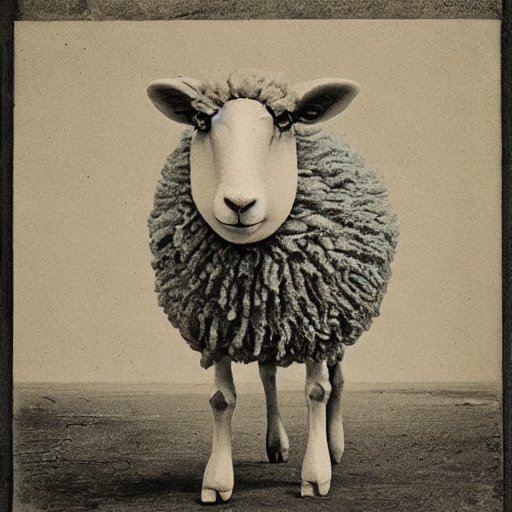

In [23]:
# Vamos a generar una imagen con un prompt: 
# tokens → input_ids → text_encoder → embedding textual → condicionamiento del UNet
prompt = "an image of a crazy sheep"
image = pipe(prompt).images[0]

image

In [ ]:
# Guardamos la imagen antes de entrenar el modelo, para poder compararla después con la imagen generada tras el entrenamiento

# Crear carpeta si no existe
os.makedirs("outputs", exist_ok=True)
# Guardar imagen dentro
image.save("outputs/image_before.png")

In [4]:
## Cargamos datos de entrenamiento
dataset_name = "gigant/oldbookillustrations"
max_train_samples = 200  # tiene que ser menor que 4172 (el numero de filas que tiene el dataset original)


dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples)) # hacemos un subset para entrenar rápido 

In [5]:
from collections import Counter

sizes = [item["1600px"].size for item in dataset]
size_counts = Counter(sizes)

widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

print(f"Total imágenes: {len(sizes)}")
print(f"Tamaños únicos: {len(size_counts)}")
print(f"Rango de anchos: {min(widths)} - {max(widths)}")
print(f"Rango de altos: {min(heights)} - {max(heights)}")

print("\n5 tamaños más frecuentes:")
for size, count in size_counts.most_common(5):
    print(f"{size}: {count}")

modes = [item["1600px"].mode for item in dataset]
mode_counts = Counter(modes)

print("\nModos encontrados:")
for mode, count in mode_counts.items():
    print(f"{mode}: {count}")

Total imágenes: 200
Tamaños únicos: 178
Rango de anchos: 943 - 1747
Rango de altos: 563 - 1600

5 tamaños más frecuentes:
(1234, 1600): 3
(1303, 1600): 3
(1282, 1600): 2
(1013, 1600): 2
(1301, 1600): 2

Modos encontrados:
RGB: 200


## Transformaciones necesarias del dataset 

- **crop + resize**: se recorta parte de la imagen para forzar la proporción objetivo y luego se redimensiona. Ventaja: se aprovecha todo el lienzo final. Desventaja: se pierde contenido/contexto.  
- **pad + resize**: se redimensiona manteniendo proporción y se rellena el espacio sobrante hasta llegar al tamaño final. Ventaja: no se pierde contenido. Desventaja: se introducen bordes vacíos o de color uniforme.

In [ ]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import functional as F

target_size = 384

def preprocess_image(image, target_size=512, fill=255):
    # 1. Forzamos escala de grises y transformamos a RGB (para que tenga 3 canales)
    image = image.convert("L").convert("RGB")

    # 2. Resize manteniendo proporción
    w, h = image.size
    scale = min(target_size / w, target_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    image = image.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # 3. Padding hasta tamaño fijo
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left
    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top

    image = F.pad(image, (pad_left, pad_top, pad_right, pad_bottom), fill=fill)

    return image

image_transforms = transforms.Compose([
    transforms.Lambda(lambda img: preprocess_image(img, target_size=target_size, fill=255)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])


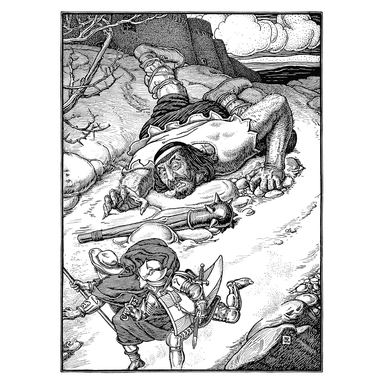

RGB (384, 384)


In [7]:
# Aplicamos la transformacion a una imagen aleatoria del dataset:
original_image = dataset[130]["1600px"]
transformed_image = image_transforms(original_image)

to_pil = transforms.ToPILImage()
# transformed_image es un tensor normalizado (en [-1,1]). ToPILImage() convierte un tensor a PIL para poder visualizarlo.
# El reescalado * 0.5 + 0.5 es porque después de Normalizar tenemos valores a rango [-1,1] 
# deshacemos la normalizacion solo para visualizar ToPILImage() 
img_pil = to_pil((transformed_image * 0.5 + 0.5).clamp(0, 1))
display(img_pil)

print(img_pil.mode, img_pil.size)


In [8]:
# Creamos un Dataset wrapper para la hora del entrenamiento:
batch_size = 2  # no puede ser mayor por la limitacion de GPU

# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

class Text2ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = image_transforms(example["1600px"]) # deja la imagen lista para el VAE 
        token = tokenizer(example["info_alt"], padding="max_length", truncation=True, max_length=tokenizer.model_max_length, return_tensors="pt") # devuelve tensor de PyTorch, si no se indica "pt" devuelve listas de python
        return {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0), # para indicar qué tokens son reales y cuáles son padding
        }

# preprocesado con el wrapper Text2ImageDataset
train_dataset = Text2ImageDataset(dataset)

sample = train_dataset[0]

print(type(sample["pixel_values"]))
print(sample["pixel_values"].shape)
print(type(sample["input_ids"]))
 
# agrupamos los ejemplos en batches, y barajamos el orden de los ejemplos en cada época (shuffle=True)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

<class 'torch.Tensor'>
torch.Size([3, 384, 384])
<class 'torch.Tensor'>


In [10]:
# Vaciamos memoria caché 
# torch.mps.empty_cache()

# Eliminamos objetos que ya no necesitemos para liberar memoria
import gc
import torch

del pipe
# del unet
# del vae
# del text_encoder
# del tokenizer
gc.collect()




750

## Cargamos los componentes del modelo

In [11]:
# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

# Scheduler:
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text Encoder (CLIP):
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
).to(device)

# VAE: Autoencoder:
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
).to(device)

# La UNet:
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
).to(device)


/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1606.35it/s, Materializing param=text_model.final_layer_norm.weight]                    
CLIPTextModel LOAD REPORT from: CompVis/stable-diffusion-v1-4
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
unet.train()
vae.eval()
text_encoder.eval()

for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

# Reduce el uso de memoria durante el entrenamiento, a cambio de hacerlo más lento 
# Especialmente importante en GPU con poca memoria, como la MPS de Mac
# Con CPU se puede usar también pero aporta menos valor, además lo hará todavía más lento
unet.disable_gradient_checkpointing()

## Preparamos el entrenamiento

In [14]:
# Optimizador:
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=1e-6
)

# Quitamos esta parte porque no usamos GPU
# # Acelerador:
# accelerator = Accelerator()
# unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)
# print(accelerator.device)

## Finetuning loop

In [15]:
# Training loop
num_epochs = 2
stop_training = False


for epoch in range(num_epochs):
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}")

    for batch in progress_bar:
        optimizer.zero_grad()

        # Pasamos los píxeles al espacio latente con el VAE
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * 0.18215

        # Ruido aleatorio
        noise = torch.randn_like(latents)

        # Un timestep distinto para cada imagen
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=latents.device
        ).long()

        # Añadimos ruido a los latentes
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Codificamos el texto
        with torch.no_grad():
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]

        # Predicción de ruido
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Loss
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        if not torch.isfinite(loss):
            print(f"Loss inválida en epoch {epoch}")
            stop_training = True
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        optimizer.step()

        progress_bar.set_postfix(loss=loss.item())

    if stop_training:
        break


Epoch 1: 100%|██████████| 100/100 [1:09:31<00:00, 41.72s/it, loss=0.0745]


In [16]:
# Guardamos el modelo finetuneado:
output_dir = "./finetuned-model"

unet.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('./finetuned-model/tokenizer_config.json', './finetuned-model/tokenizer.json')

## Cargamos el modelo ya finetuneado para generar imágenes

In [1]:
from diffusers import StableDiffusionPipeline, UNet2DConditionModel

import gc
import torch

gc.collect()

/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/gloriadelriomarquez/Documents/Career/Master Pontia/7. Modelos gen imagen/Entrega/.venv/lib/python3.13/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


173

In [3]:
# Cargamos la u-net enternada del repo de hugging face o desde local: 
# finetuned_unet = UNet2DConditionModel.from_pretrained("gloriadrm/finetuned-oldbook-unet")
pretrained_model_name = "CompVis/stable-diffusion-v1-4"
finetuned_unet = UNet2DConditionModel.from_pretrained("../finetuned-model")
device = torch.device("cpu")

pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=finetuned_unet,
).to(device)

pipe.enable_attention_slicing() 

print("Modelo finetuneado cargado y listo para ejecutar!")


Loading weights: 100%|██████████| 396/396 [00:00<00:00, 463.76it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: /Users/gloriadelriomarquez/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 398.23it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/gloriadelriomarquez/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status    

Modelo finetuneado cargado y listo para ejecutar!


100%|██████████| 30/30 [01:13<00:00,  2.45s/it]


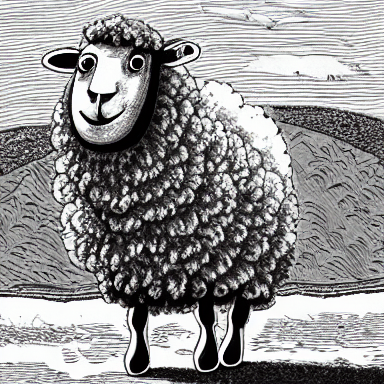

: 

In [ ]:
# Generamos la imagen con el modelo finetuneado:
prompt = "an image of a crazy sheep"
image = pipe(prompt, height=384, width=384, num_inference_steps=30, guidance_scale=7.5).images[0]

display(image)

In [ ]:
# Guardamos la imagen generada tras el entrenamiento para compararla con la imagen generada antes del entrenamiento
image.save("outputs/image_after.png")

## Dificultades encontradas

Una vez entrenada la U-net, comenzamos a tener problemas de limitación de recursos. Cada vez que intentábamos generar una imagen, tanto con el modelo base de Stable Diffusion como con el modelo fine-tuneado, obteníamos el siguiente error:

<p style="color: red;"><strong>The Kernel crashed while executing code in the current cell or a previous cell.</strong></p>

Probamos a reducir el número de `steps` y la resolución de las imágenes hasta llegar a `128x128` y `5 steps`, configuración con la que al menos conseguíamos una salida, aunque poco representativa a nivel visual. Por este motivo no llegamos a validar completamente el código de `src/` y decidimos finalizar la entrega utilizando el notebook como flujo principal.


In [4]:
# Generamos la imagen con el modelo finetuneado:
prompt = "an image of a crazy sheep"
image = pipe(prompt, height=256, width=256, num_inference_steps=20, guidance_scale=7.5).images[0]

display(image)

100%|██████████| 20/20 [00:38<00:00,  1.92s/it]


: 